# Business Case #1 — Segmenting Bank Clients
**Politecnico di Milano — FinTech Lab**

Goal: segment 5,000 bank clients into meaningful Personas using Unsupervised ML (K-Means + alternatives).

---
## Pipeline
1. Load & Explore Data
2. Preprocessing (already done — reproduced here for completeness)
3. Find optimal k (Elbow + Silhouette)
4. Apply K-Means
5. Interpret Clusters → Personas
6. Visualizations
7. Alternative: Hierarchical Clustering
8. Assign new clients to Personas

---
## 1. Load & Explore Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from scipy.cluster.hierarchy import dendrogram, linkage

# Load data
df = pd.read_excel('Dataset1_BankClients.xlsx')
df = df.drop(columns=['ID'])

print('--- Dataset Shape ---')
print(f'{df.shape[0]} clients, {df.shape[1]} features')

print('\n--- First 5 rows ---')
display(df.head())

print('\n--- Descriptive Statistics ---')
display(df.describe().round(2))

--- Dataset Shape ---
5000 clients, 17 features

--- First 5 rows ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2



--- Descriptive Statistics ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,60.45,0.53,2.46,1.38,1.93,2.49,0.58,0.58,0.43,0.51,0.59,0.53,0.62,0.46,0.47,0.52,2.18
std,21.82,0.50,1.25,0.68,0.76,1.41,0.21,0.21,0.22,0.19,0.17,0.21,0.16,0.22,0.24,0.19,0.82
min,19.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.12,0.00,0.00,0.00,1.00
25%,42.00,0.00,2.00,1.00,1.00,1.00,0.41,0.42,0.26,0.37,0.47,0.37,0.51,0.28,0.27,0.40,1.00
50%,61.00,1.00,2.00,1.00,2.00,2.00,0.58,0.59,0.45,0.50,0.60,0.52,0.63,0.45,0.46,0.54,2.00
75%,80.00,1.00,2.00,2.00,3.00,3.00,0.75,0.75,0.60,0.65,0.71,0.70,0.75,0.64,0.66,0.66,3.00
max,95.00,1.00,5.00,3.00,3.00,6.00,0.98,1.00,0.98,0.96,0.99,0.97,0.97,0.99,1.00,0.97,3.00


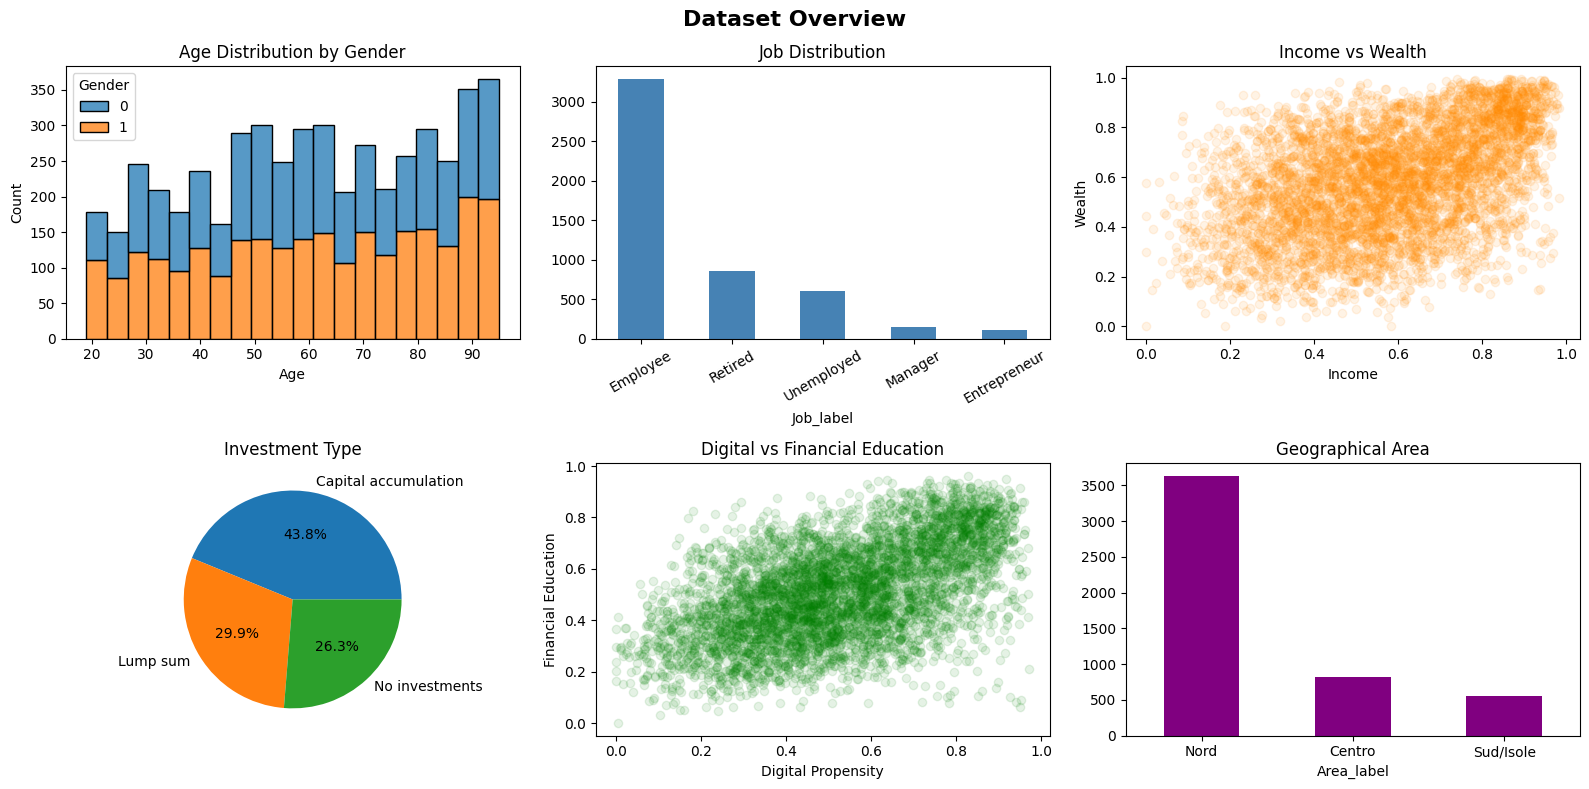

In [2]:
# Quick visual overview of the dataset
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# Age distribution by gender
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', bins=20, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Gender')

# Job distribution
job_labels = {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'}
df['Job_label'] = df['Job'].map(job_labels)
df['Job_label'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Job Distribution')
axes[0,1].tick_params(axis='x', rotation=30)

# Income vs Wealth
axes[0,2].scatter(df['Income'], df['Wealth'], alpha=0.1, color='darkorange')
axes[0,2].set_xlabel('Income')
axes[0,2].set_ylabel('Wealth')
axes[0,2].set_title('Income vs Wealth')

# Investments distribution
inv_labels = {1:'No investments', 2:'Lump sum', 3:'Capital accumulation'}
df['Inv_label'] = df['Investments'].map(inv_labels)
df['Inv_label'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Investment Type')
axes[1,0].set_ylabel('')

# Digital vs FinEdu
axes[1,1].scatter(df['Digital'], df['FinEdu'], alpha=0.1, color='green')
axes[1,1].set_xlabel('Digital Propensity')
axes[1,1].set_ylabel('Financial Education')
axes[1,1].set_title('Digital vs Financial Education')

# Area distribution
area_labels = {1:'Nord', 2:'Centro', 3:'Sud/Isole'}
df['Area_label'] = df['Area'].map(area_labels)
df['Area_label'].value_counts().plot(kind='bar', ax=axes[1,2], color='purple')
axes[1,2].set_title('Geographical Area')
axes[1,2].tick_params(axis='x', rotation=0)

# Drop helper columns
df = df.drop(columns=['Job_label', 'Inv_label', 'Area_label'])

plt.tight_layout()
plt.show()

---
## 2. Preprocessing

We treat the features in 3 groups:
- **Already scaled** (0–1 percentiles): Income, Wealth, Debt, FinEdu, ESG, Digital, BankFriend, LifeStyle, Luxury, Saving, Gender → taken as-is
- **Ordered categorical**: Age, CitySize, FamilySize → MinMaxScaler
- **Unordered categorical**: Job, Area, Investments → OneHotEncoder (drop='first')

In [3]:
# --- Unordered categorical → One-Hot Encoding ---
no_order_columns = ['Job', 'Area', 'Investments']
no_order_features = df[no_order_columns].astype('category')

encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
X_no_order = encoder.fit_transform(no_order_features).toarray()

# --- Ordered categorical → MinMaxScaler ---
order_columns = ['Age', 'CitySize', 'FamilySize']
order_features = df[order_columns]

scaler = MinMaxScaler()
X_order = scaler.fit_transform(order_features)

# --- Already scaled → take as-is ---
already_scaled_columns = ['Gender', 'Income', 'Wealth', 'Debt', 'FinEdu',
                           'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']
X_num = df[already_scaled_columns].values

# --- Final matrix ---
X = np.hstack((X_num, X_order, X_no_order))

# Build named DataFrame for inspection
encoded_column_names = encoder.get_feature_names_out(no_order_columns).tolist()
all_columns = already_scaled_columns + order_columns + encoded_column_names
df_scaled = pd.DataFrame(X, columns=all_columns)

print(f'Matrix X shape: {X.shape}')  # should be (5000, 11+3+encoded)
display(df_scaled.head())

Matrix X shape: (5000, 22)


,Gender,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,...,CitySize,FamilySize,Job_2,Job_3,Job_4,Job_5,Area_2,Area_3,Investments_2,Investments_3
0,1.0,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,...,0.5,0.6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,...,0.5,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,...,0.5,0.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)  # mantieni 90% della varianza
X_pca = pca.fit_transform(df_scaled)

print(f'Dimensioni ridotte: {X_pca.shape[1]} componenti')
print(f'Varianza spiegata per componente: {pca.explained_variance_ratio_.round(3)}')
print(f'Varianza totale spiegata: {pca.explained_variance_ratio_.sum():.2%}')

# Se vuoi vedere come DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
print(df_pca.head())

Dimensioni ridotte: 13 componenti
Varianza spiegata per componente: [0.225 0.148 0.119 0.093 0.068 0.046 0.043 0.041 0.035 0.033 0.028 0.016
 0.015]
Varianza totale spiegata: 90.93%
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.271206 -0.028180  0.525442  0.379498  0.787706 -0.666922 -0.167899   
1  1.002660  0.066115  0.703080  0.651889  0.846215  0.055213  0.275956   
2  0.937674  0.012437 -0.402457  0.332695 -0.054050  0.145791 -0.171723   
3 -0.133057  0.870581 -0.463645 -0.253904 -0.058326  0.259445 -0.037905   
4  0.261761  1.311575 -0.239008  0.487662 -0.050644  0.141523 -0.056569   

        PC8       PC9      PC10      PC11      PC12      PC13  
0 -0.635356  0.362740 -0.070156 -0.047436 -0.363884  0.066657  
1 -0.175545 -0.194614  0.306951  0.015284  0.029222 -0.089526  
2 -0.145255 -0.100645  0.118747 -0.161819 -0.258358  0.122962  
3  0.178993  0.116012 -0.099896  0.056951  0.179782 -0.072263  
4 -0.002417 -0.165170 -0.001759 -0.177710  0.17

---
## 3. Find Optimal k — Elbow + Silhouette

Computing KMeans for k = 2 to 14...
  k=2 | Inertia: 7714.1 | Silhouette: 0.2175
  k=3 | Inertia: 6516.0 | Silhouette: 0.1967
  k=4 | Inertia: 5911.3 | Silhouette: 0.1891
  k=5 | Inertia: 5491.0 | Silhouette: 0.1895
  k=6 | Inertia: 5192.6 | Silhouette: 0.1882
  k=7 | Inertia: 4948.2 | Silhouette: 0.1914
  k=8 | Inertia: 4704.1 | Silhouette: 0.1987
  k=9 | Inertia: 4513.2 | Silhouette: 0.1954
  k=10 | Inertia: 4357.2 | Silhouette: 0.1971
  k=11 | Inertia: 4168.1 | Silhouette: 0.2031
  k=12 | Inertia: 4118.9 | Silhouette: 0.2095
  k=13 | Inertia: 3967.0 | Silhouette: 0.1981
  k=14 | Inertia: 3834.1 | Silhouette: 0.1889


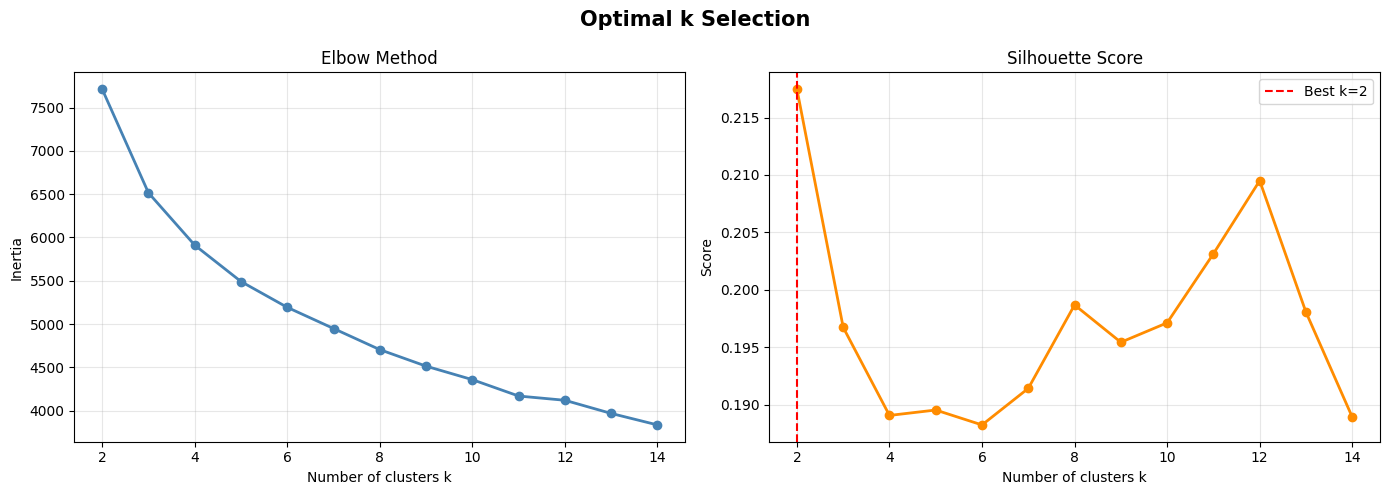


Best k by Silhouette: 2
→ Also inspect the Elbow plot and choose k where inertia drop slows down.


In [13]:
inertie = []
silhouette_scores = []
k_range = range(2, 15)

print('Computing KMeans for k = 2 to 14...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    inertie.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))
    print(f'  k={k} | Inertia: {kmeans.inertia_:.1f} | Silhouette: {silhouette_score(X_pca, kmeans.labels_):.4f}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k Selection', fontsize=15, fontweight='bold')

ax1.plot(k_range, inertie, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

best_k_sil = k_range[silhouette_scores.index(max(silhouette_scores))]
ax2.plot(k_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nBest k by Silhouette: {best_k_sil}')
print('→ Also inspect the Elbow plot and choose k where inertia drop slows down.')

---
## 4. Apply K-Means with chosen k

> **Change `K_CHOSEN` below based on the plots above.**

In [25]:
# ← Change this value based on the Elbow + Silhouette plots
best_k_sil=8
#con 8 è più semplice gestire le personas e fare il pp ma avrà una ricchezza di segmentazione minore mentre con 10 
#sarà maggiore ma avremo una complessitò interpretativa più alta
K_CHOSEN = best_k_sil

kmeans_final = KMeans(n_clusters=K_CHOSEN, n_init=20, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X)

# Cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()
print('--- Cluster Sizes ---')
for i, size in cluster_sizes.items():
    print(f'  Cluster {i}: {size} clients ({size/len(df)*100:.1f}%)')

--- Cluster Sizes ---
  Cluster 0: 816 clients (16.3%)
  Cluster 1: 507 clients (10.1%)
  Cluster 2: 512 clients (10.2%)
  Cluster 3: 543 clients (10.9%)
  Cluster 4: 840 clients (16.8%)
  Cluster 5: 789 clients (15.8%)
  Cluster 6: 516 clients (10.3%)
  Cluster 7: 477 clients (9.5%)


---
## 5. Interpret Clusters → Personas

We analyze the **original (unscaled)** feature means per cluster to understand who each Persona is.

In [26]:
# --- Centroid analysis on original data ---
cluster_profile = df.groupby('Cluster').mean().round(2)

print('--- Cluster Centroids (original values) ---')
display(cluster_profile)

# Map readable labels for categorical features
job_labels = {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'}
area_labels = {1:'Nord', 2:'Centro', 3:'Sud/Isole'}
inv_labels  = {1:'No investments', 2:'Lump sum', 3:'Capital acc.'}

print('\n--- Key Features by Cluster ---')
summary = pd.DataFrame({
    'Cluster':      range(K_CHOSEN),
    'N clients':    [cluster_sizes[i] for i in range(K_CHOSEN)],
    'Avg Age':      cluster_profile['Age'].values,
    'Gender (F=1)': cluster_profile['Gender'].round(2).values,
    'Avg Job':      [job_labels[round(cluster_profile['Job'][i])] for i in range(K_CHOSEN)],
    'Income':       cluster_profile['Income'].values,
    'Wealth':       cluster_profile['Wealth'].values,
    'FinEdu':       cluster_profile['FinEdu'].values,
    'Digital':      cluster_profile['Digital'].values,
    'Investments':  [inv_labels[round(cluster_profile['Investments'][i])] for i in range(K_CHOSEN)]
})
display(summary)
# --- Distribuzione reale delle variabili categoriche per cluster ---
df_scaled['Cluster'] = df['Cluster']

categorical_groups = {
    'Job':         {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'},
    'Area':        {1:'Nord', 2:'Centro', 3:'Sud/Isole'},
    'Investments': {1:'No investments', 2:'Lump sum', 3:'Capital acc.'}
}

for var, labels in categorical_groups.items():
    cols = [col for col in df_scaled.columns if col.startswith(var)]
    dist = df_scaled.groupby('Cluster')[cols].mean().round(3) * 100
    
    # Ricalcola la prima categoria (eliminata da drop='first')
    dist.insert(0, list(labels.values())[0], 100 - dist.sum(axis=1))
    dist.columns = list(labels.values())
    
    print(f'\n--- {var} distribution per cluster (%) ---')
    display(dist.round(1))

--- Cluster Centroids (original values) ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
Cluster,,,,,,,,,,,,,,,,,
0,57.01,0.00,2.00,1.36,1.92,2.68,0.64,0.63,0.52,0.56,0.57,0.58,0.62,0.51,0.53,0.58,3.00
1,78.50,0.65,4.00,1.44,1.63,2.08,0.40,0.41,0.14,0.35,0.62,0.31,0.64,0.26,0.26,0.34,2.00
2,55.47,0.00,2.00,1.33,2.17,2.48,0.67,0.69,0.52,0.61,0.59,0.63,0.67,0.56,0.60,0.58,2.00
3,52.45,0.60,2.02,1.30,2.12,2.34,0.62,0.60,0.44,0.52,0.59,0.60,0.61,0.55,0.55,0.53,2.32
4,56.20,1.00,2.00,1.37,1.97,2.63,0.60,0.61,0.50,0.55,0.59,0.56,0.60,0.50,0.50,0.57,3.00
5,57.62,0.51,2.00,1.46,1.81,2.77,0.58,0.58,0.49,0.51,0.56,0.54,0.59,0.46,0.46,0.57,1.00
6,77.67,0.52,4.47,1.45,1.67,2.23,0.41,0.42,0.20,0.37,0.60,0.35,0.63,0.28,0.29,0.36,1.68
7,55.12,1.00,2.04,1.36,2.16,2.33,0.63,0.64,0.51,0.58,0.60,0.60,0.62,0.53,0.57,0.57,2.00



--- Key Features by Cluster ---


,Cluster,N clients,Avg Age,Gender (F=1),Avg Job,Income,Wealth,FinEdu,Digital,Investments
0,0,816,57.01,0.00,Employee,0.64,0.63,0.56,0.58,Capital acc.
1,1,507,78.50,0.65,Entrepreneur,0.40,0.41,0.35,0.31,Lump sum
2,2,512,55.47,0.00,Employee,0.67,0.69,0.61,0.63,Lump sum
3,3,543,52.45,0.60,Employee,0.62,0.60,0.52,0.60,Lump sum
4,4,840,56.20,1.00,Employee,0.60,0.61,0.55,0.56,Capital acc.
5,5,789,57.62,0.51,Employee,0.58,0.58,0.51,0.54,No investments
6,6,516,77.67,0.52,Entrepreneur,0.41,0.42,0.37,0.35,Lump sum
7,7,477,55.12,1.00,Employee,0.63,0.64,0.58,0.60,Lump sum



--- Job distribution per cluster (%) ---


,Unemployed,Employee,Manager,Entrepreneur,Retired
Cluster,,,,,
0,0.0,100.0,0.0,0.0,0.0
1,23.8,0.0,1.0,2.6,72.6
2,9.8,85.9,1.2,1.0,2.1
3,60.7,0.0,21.0,13.1,5.2
4,0.0,100.0,0.0,0.0,0.0
5,0.0,100.0,0.0,0.0,0.0
6,12.9,0.0,0.0,1.2,85.9
7,8.6,83.6,4.0,2.5,1.3



--- Area distribution per cluster (%) ---


,Nord,Centro,Sud/Isole
Cluster,,,
0,75.8,12.6,11.6
1,65.1,25.4,9.5
2,78.0,11.1,10.9
3,78.6,13.1,8.3
4,74.2,14.6,11.2
5,68.2,17.6,14.2
6,64.0,26.9,9.1
7,75.7,13.0,11.3



--- Investments distribution per cluster (%) ---


,No investments,Lump sum,Capital acc.
Cluster,,,
0,0.0,0.0,100.0
1,0.0,100.0,0.0
2,0.0,100.0,0.0
3,34.1,0.0,65.9
4,0.0,0.0,100.0
5,100.0,0.0,0.0
6,65.9,0.0,34.1
7,0.0,100.0,0.0


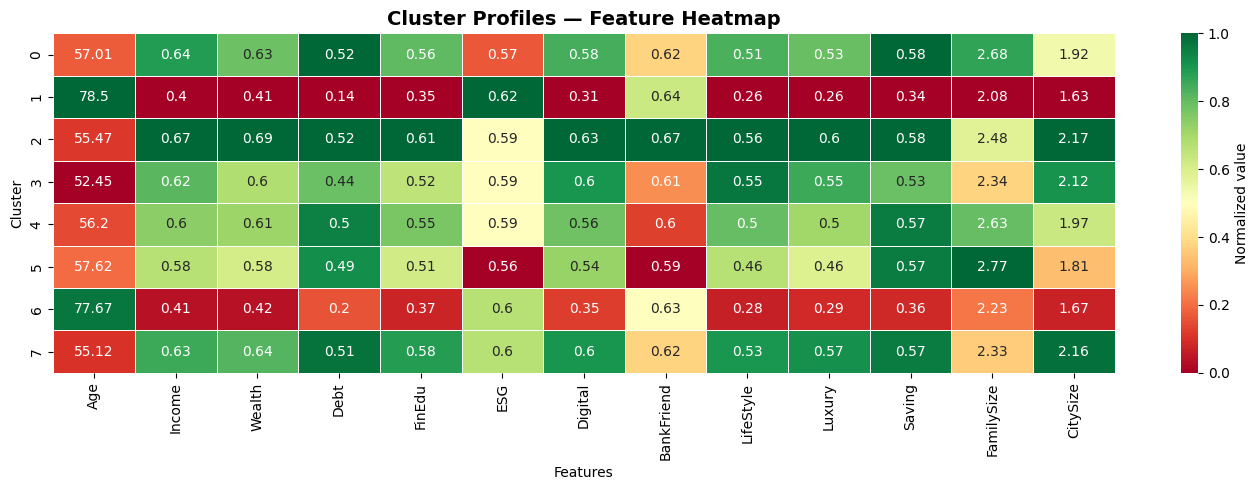

In [21]:
# --- Heatmap of cluster profiles ---
# Select most meaningful numerical features
features_to_plot = ['Age', 'Income', 'Wealth', 'Debt', 'FinEdu',
                    'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving',
                    'FamilySize', 'CitySize']

# Normalize cluster means to 0-1 for comparison
heatmap_data = cluster_profile[features_to_plot]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='g',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Normalized value'})
plt.title('Cluster Profiles — Feature Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

---
## 6. Visualizations

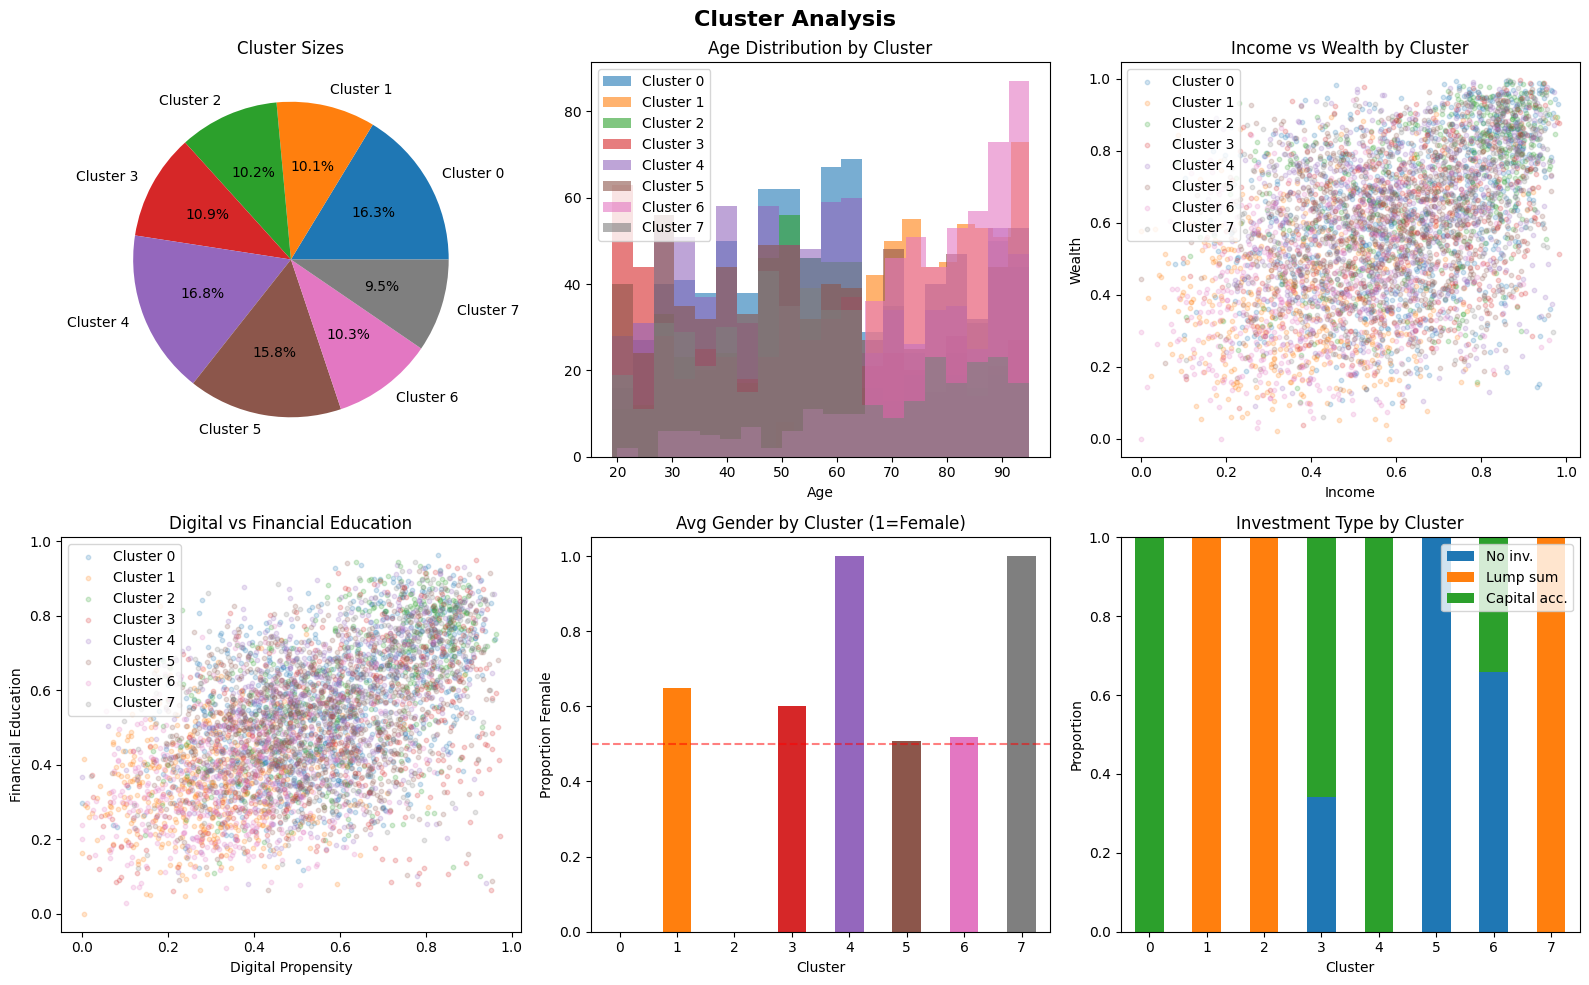

In [22]:
# --- Cluster size distribution ---
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cluster Analysis', fontsize=16, fontweight='bold')

# Pie chart of cluster sizes
axes[0,0].pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index],
              autopct='%1.1f%%', colors=colors[:K_CHOSEN])
axes[0,0].set_title('Cluster Sizes')

# Age distribution by cluster
for i in range(K_CHOSEN):
    axes[0,1].hist(df[df['Cluster']==i]['Age'], bins=20, alpha=0.6,
                   label=f'Cluster {i}', color=colors[i])
axes[0,1].set_title('Age Distribution by Cluster')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Income vs Wealth colored by cluster
for i in range(K_CHOSEN):
    mask = df['Cluster'] == i
    axes[0,2].scatter(df[mask]['Income'], df[mask]['Wealth'],
                      alpha=0.2, color=colors[i], label=f'Cluster {i}', s=10)
axes[0,2].set_title('Income vs Wealth by Cluster')
axes[0,2].set_xlabel('Income')
axes[0,2].set_ylabel('Wealth')
axes[0,2].legend()

# Digital vs FinEdu
for i in range(K_CHOSEN):
    mask = df['Cluster'] == i
    axes[1,0].scatter(df[mask]['Digital'], df[mask]['FinEdu'],
                      alpha=0.2, color=colors[i], label=f'Cluster {i}', s=10)
axes[1,0].set_title('Digital vs Financial Education')
axes[1,0].set_xlabel('Digital Propensity')
axes[1,0].set_ylabel('Financial Education')
axes[1,0].legend()

# Gender by cluster
gender_by_cluster = df.groupby('Cluster')['Gender'].mean()
gender_by_cluster.plot(kind='bar', ax=axes[1,1], color=colors[:K_CHOSEN])
axes[1,1].set_title('Avg Gender by Cluster (1=Female)')
axes[1,1].set_ylabel('Proportion Female')
axes[1,1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[1,1].tick_params(axis='x', rotation=0)

# Investment type by cluster
inv_by_cluster = df.groupby(['Cluster', 'Investments']).size().unstack(fill_value=0)
inv_by_cluster.columns = ['No inv.', 'Lump sum', 'Capital acc.']
inv_by_cluster.div(inv_by_cluster.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[1,2], stacked=True)
axes[1,2].set_title('Investment Type by Cluster')
axes[1,2].set_ylabel('Proportion')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(loc='upper right')

plt.tight_layout()
plt.show()

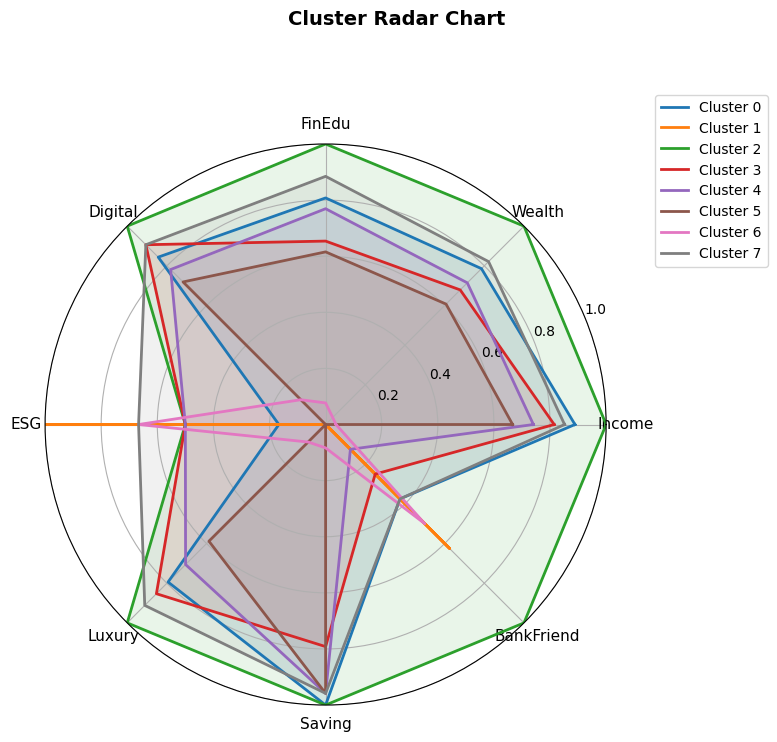

In [27]:
# --- Radar chart for cluster profiles ---
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_features = ['Income', 'Wealth', 'FinEdu', 'Digital', 'ESG',
                  'Luxury', 'Saving', 'BankFriend']

# Normalize to 0-1
radar_data = cluster_profile[radar_features]
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Cluster Radar Chart', fontsize=14, fontweight='bold')

for i in range(K_CHOSEN):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, color=colors[i], label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 7. Alternative Approach — Hierarchical Clustering

We compare K-Means with Agglomerative Clustering (Ward method) to validate our segmentation.

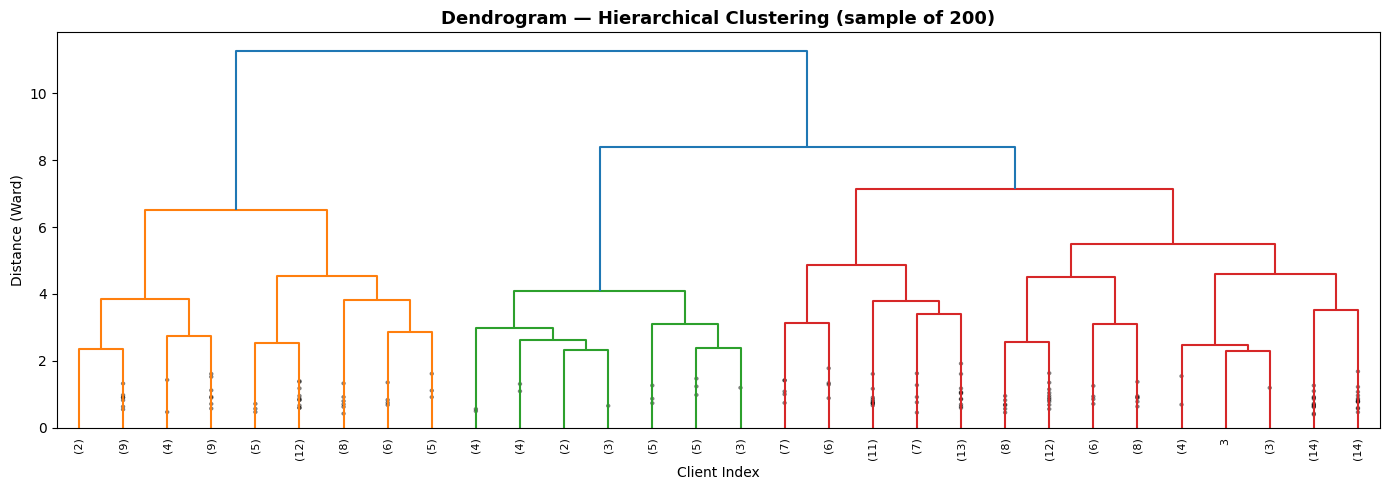

In [28]:
# Dendrogram on a sample (full dataset is too large to visualize)
np.random.seed(42)
sample_idx = np.random.choice(len(X), 200, replace=False)
X_sample = X[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
plt.title('Dendrogram — Hierarchical Clustering (sample of 200)', fontsize=13, fontweight='bold')
plt.xlabel('Client Index')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [29]:
# Apply Agglomerative Clustering with same k
agglo = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage='ward')
df['Cluster_Agglo'] = agglo.fit_predict(X)

# Compare Silhouette scores
sil_kmeans = silhouette_score(X, df['Cluster'])
sil_agglo  = silhouette_score(X, df['Cluster_Agglo'])

print('--- Comparison: K-Means vs Hierarchical ---')
print(f'  K-Means      Silhouette: {sil_kmeans:.4f}')
print(f'  Hierarchical Silhouette: {sil_agglo:.4f}')
print(f'  → Better method: {"K-Means" if sil_kmeans >= sil_agglo else "Hierarchical"}')

# Cluster sizes comparison
print('\n--- Cluster sizes ---')
print('K-Means:     ', df['Cluster'].value_counts().sort_index().to_dict())
print('Hierarchical:', df['Cluster_Agglo'].value_counts().sort_index().to_dict())

--- Comparison: K-Means vs Hierarchical ---
  K-Means      Silhouette: 0.1609
  Hierarchical Silhouette: 0.1241
  → Better method: K-Means

--- Cluster sizes ---
K-Means:      {0: 816, 1: 507, 2: 512, 3: 543, 4: 840, 5: 789, 6: 516, 7: 477}
Hierarchical: {0: 963, 1: 636, 2: 600, 3: 658, 4: 618, 5: 471, 6: 431, 7: 623}


---
## 8. Assign a New Client to a Persona

After training, any new client can be assigned to the closest Persona using the same preprocessing pipeline.

In [30]:
# Example: new client to classify
new_client = pd.DataFrame([{
    'Age': 45,
    'Gender': 1,        # Female
    'Job': 3,           # Manager
    'Area': 1,          # Nord
    'CitySize': 3,      # Large city
    'FamilySize': 2,
    'Income': 0.75,
    'Wealth': 0.80,
    'Debt': 0.20,
    'FinEdu': 0.85,
    'ESG': 0.70,
    'Digital': 0.90,
    'BankFriend': 0.65,
    'LifeStyle': 0.75,
    'Luxury': 0.60,
    'Saving': 0.55,
    'Investments': 3    # Capital accumulation
}])

# Apply same preprocessing
X_new_no_order = encoder.transform(new_client[no_order_columns].astype('category')).toarray()
X_new_order    = scaler.transform(new_client[order_columns])
X_new_num      = new_client[already_scaled_columns].values
X_new          = np.hstack((X_new_num, X_new_order, X_new_no_order))

# Predict cluster
predicted_cluster = kmeans_final.predict(X_new)[0]

print(f'New client assigned to: Cluster {predicted_cluster}')
print(f'\nCluster {predicted_cluster} profile:')
display(cluster_profile.loc[predicted_cluster, ['Age','Income','Wealth','FinEdu','Digital','Investments']].to_frame().T)

New client assigned to: Cluster 3

Cluster 3 profile:


,Age,Income,Wealth,FinEdu,Digital,Investments
3,52.45,0.62,0.6,0.52,0.6,2.32


---
## 9. Personas — Summary

> **Fill in the persona names and descriptions after analyzing the heatmap and cluster profiles above.**

| Cluster | Persona Name | Key Traits | Main Needs | Service Model |
|---------|-------------|-----------|------------|---------------|
| 0 | *(e.g. Young Digital)* | Young, high digital, low wealth | Savings, first investments | Digital |
| 1 | *(e.g. Wealthy Retiree)* | Older, high wealth, low digital | Capital protection, inheritance | Physical |
| ... | ... | ... | ... | ... |